In [ ]:
import pandas as pd


file_path = "1_blast_furnace_data_first_dataset.xlsx"

df_data = pd.read_excel(file_path, sheet_name='data')
df_si = pd.read_excel(file_path, sheet_name='Si')

df_data.info()
df_si.info()

display(df_data.head(5))
display(df_si.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29602 entries, 0 to 29601
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   dt      29602 non-null  object 
 1   Fb      29602 non-null  float64
 2   Ph      29602 non-null  float64
 3   Pc      29602 non-null  float64
 4   Tc      29602 non-null  float64
 5   Fo      29602 non-null  float64
 6   dP      29602 non-null  float64
 7   dPu     29602 non-null  float64
 8   dPl     29602 non-null  float64
 9   Pt      29602 non-null  float64
 10  Th      29602 non-null  float64
 11  CO2     29602 non-null  float64
 12  H2      29602 non-null  float64
 13  Tt1     29602 non-null  float64
 14  Tt2     29602 non-null  float64
 15  Tt3     29602 non-null  float64
 16  Tt4     29602 non-null  float64
 17  Tp1     29602 non-null  float64
 18  Tp2     29602 non-null  float64
 19  Tp3     29602 non-null  float64
 20  Tp4     29602 non-null  float64
 21  Tp5     29602 non-null  float64
 22

,dt,Fb,Ph,Pc,Tc,Fo,dP,dPu,dPl,Pt,...,Tp2,Tp3,Tp4,Tp5,Tp6,Tp7,Tp8,Tp9,Tp10,R
0,2013-01-01 00:00:00.000,3488.40,2.77,2.89,82.08,12511.37,1.47,0.54,0.93,1.30,...,711.22,695.53,528.45,511.66,557.98,531.63,364.04,326.60,382.85,3.84
1,2013-01-01 01:00:00.000,3514.32,2.78,2.91,81.60,15091.73,1.48,0.55,0.93,1.30,...,670.27,608.44,479.42,492.85,483.20,455.37,333.48,301.20,336.32,3.83
2,2013-01-01 02:00:00.000,3509.19,2.81,2.94,81.51,16910.19,1.52,0.58,0.94,1.30,...,665.66,599.67,450.30,459.69,435.77,402.08,312.06,279.43,335.72,3.81
3,2013-01-01 03:00:00.000,3504.78,2.80,2.96,80.68,17102.40,1.50,0.54,0.96,1.30,...,626.72,532.38,418.98,433.73,391.76,361.85,281.23,245.95,314.39,3.80
4,2013-01-01 04:00:00.000,3535.08,2.82,2.94,80.69,16821.54,1.51,0.52,0.99,1.31,...,626.29,541.74,431.59,428.51,394.17,362.35,276.63,241.76,305.69,3.84


,dt,Si
0,2013-01-01 00:55:00.000,0.50
1,2013-01-01 02:55:00.000,0.50
2,2013-01-01 04:40:00.000,0.62
3,2013-01-01 06:10:00.000,0.62
4,2013-01-01 07:50:00.000,0.60


In [2]:
df_data['dt'] = pd.to_datetime(df_data['dt'])
df_si['dt']   = pd.to_datetime(df_si['dt'])

df_data.info()
df_si.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29602 entries, 0 to 29601
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   dt      29602 non-null  datetime64[ns]
 1   Fb      29602 non-null  float64       
 2   Ph      29602 non-null  float64       
 3   Pc      29602 non-null  float64       
 4   Tc      29602 non-null  float64       
 5   Fo      29602 non-null  float64       
 6   dP      29602 non-null  float64       
 7   dPu     29602 non-null  float64       
 8   dPl     29602 non-null  float64       
 9   Pt      29602 non-null  float64       
 10  Th      29602 non-null  float64       
 11  CO2     29602 non-null  float64       
 12  H2      29602 non-null  float64       
 13  Tt1     29602 non-null  float64       
 14  Tt2     29602 non-null  float64       
 15  Tt3     29602 non-null  float64       
 16  Tt4     29602 non-null  float64       
 17  Tp1     29602 non-null  float64       
 18  Tp2   

In [3]:
df_data = df_data.sort_values('dt')
df_si   = df_si.  sort_values('dt')

In [4]:
df_data_temp = df_data.rename(columns={'dt': 'sensor_dt'})
df_merged= pd.merge_asof(df_si, df_data_temp, left_on='dt', right_on='sensor_dt', direction='backward')

df_merged['zaman_farki_dk'] = (df_merged['dt'] - df_merged['sensor_dt']).dt.total_seconds() / 60

print("Zaman Kayması (Drift) Analizi:")
print(df_merged['zaman_farki_dk'].describe(percentiles=[.01, .5, .95, .99]))

Zaman Kayması (Drift) Analizi:
count    16589.000000
mean        27.664235
std         17.285074
min          0.000000
1%           0.000000
50%         30.000000
95%         55.000000
99%         55.000000
max         59.000000
Name: zaman_farki_dk, dtype: float64


Metot (Asynchronous Join): Sensör verileri saatlik, laboratuvar verileri ise düzensizdi. Bu yüzden Pandas'ın merge_asof fonksiyonunu kullanarak 'backward' (geriye dönük) bir eşleştirme yapıldı. Yani her Silisyum sonucuna, o andaki fırın durumunu en iyi temsil eden son kayıtlı sensör verisini atandı.

Doğrulama (Data Fidelity Check): iki zaman damgası arasındaki farkı (time gap) hesaplayıp istatistiksel bir analiz yapıldı Verilerimin %99'unun 55 dakikadan daha az bir farkla eşleştiğini görüntülendi.

Mühendislik Kararı (Tolerance): Sensör kayıt periyodu 60 dakika olduğu için, bu 55 dakikalık maksimum fark benim için kabul edilebilirdi. Eğer aradaki fark 2-3 saat olsaydı, o veriyi 'tutarsız' kabul edip analiz dışı bırakalacaktı.


In [5]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16589 entries, 0 to 16588
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   dt              16589 non-null  datetime64[ns]
 1   Si              16589 non-null  float64       
 2   sensor_dt       16589 non-null  datetime64[ns]
 3   Fb              16589 non-null  float64       
 4   Ph              16589 non-null  float64       
 5   Pc              16589 non-null  float64       
 6   Tc              16589 non-null  float64       
 7   Fo              16589 non-null  float64       
 8   dP              16589 non-null  float64       
 9   dPu             16589 non-null  float64       
 10  dPl             16589 non-null  float64       
 11  Pt              16589 non-null  float64       
 12  Th              16589 non-null  float64       
 13  CO2             16589 non-null  float64       
 14  H2              16589 non-null  float64       
 15  Tt

Grup 1: Besleme ve Girdi

In [6]:
besleme_girdi = ['Fb', 'Fo', 'Th', 'Tc', 'R']

besleme_kimlik = df_merged[besleme_girdi].describe(percentiles =[.01, .05, .5, .95, .99])

print("1. GRUP: BESLEME VE GİRDİ GRUBU ANALİZİ")
print(besleme_kimlik.round(3))

1. GRUP: BESLEME VE GİRDİ GRUBU ANALİZİ
              Fb         Fo         Th         Tc          R
count  16589.000  16589.000  16589.000  16589.000  16589.000
mean    3608.441  17999.956   1060.052    102.569      4.027
std      447.415   4158.505     77.382     12.879      0.425
min        0.000      0.000     -6.930      0.000      0.000
1%       925.940      0.000    838.146     68.930      2.849
5%      3203.538  11306.470    952.428     81.670      3.730
50%     3661.780  18187.440   1071.590    102.750      4.000
95%     3992.936  23686.880   1140.050    122.820      4.560
99%     4074.144  25607.065   1152.130    127.976      4.700
max     4219.980  29849.150   1374.440    135.880     14.640


Fb (Hava Debisi): Sistemin ana motoru.

Fo (Oksijen Debisi): Yanmayı hızlandıran katkı. (Fb ile doğrudan korelasyonu olmalı).

Th (Sıcak Hava Sıcaklığı): Fırına giren enerjinin seviyesi.

Tc (Soğuk Hava Sıcaklığı): Giriş havasının referans noktası.

R (Cevher/Kok Oranı): Fırının içine ne kadar "yakıt" ve ne kadar "hammadde" koyduğumuzun dengesi.

Fiziksel İmkansızlık Kontrolü: Fb, Fo, Tc ve R asla negatif olamaz. Th (Sıcak hava) fırın çalışırken asla eksiye düşmez (oda sıcaklığının bile altına inemez).

Termodinamik Kuralı ($Th > Tc$): Hava, ısıtıcılardan (Stoves) geçtikten sonra fırına girer. Dolayısıyla fırına giren "Sıcak Hava" ($Th$), mutlaka "Soğuk Hava"dan ($Tc$) daha sıcak olmalıdır. Eğer tersiyse o satırda veri kayması vardır.

Mantıksal Korelasyon: Eğer Fb (Hava debisi) 0 ise (fırın durmuşsa), Fo (Oksijen) da 0 olmalıdır. Birisi 0 iken diğeri yüksekse o sensör o an "donmuş" demektir.

Rejim Filtresi Fb > 500, Fırın dururken ya da rölantideyken kaydedilen verilerde basınç ve sıcaklık dengeleri farklı davranabilir. Si tahmini yapmak istiyorsak üretim olmayan andaki veriyi modele öğretmek modele yanlış bir fırın karakteri öğretmekle sonuçlanabilir.

In [7]:
mask_group1 = (
    (df_merged['Th'] > df_merged['Tc']) &      # Isıl denge kuralı
    (df_merged['Th'] >= 0)  &                  # Eksi sıcaklık olamaz
    (df_merged['Tc'] >= 0)  & 
    (df_merged['Fo'] >= 0)  &
    (df_merged['Fb'] > 500) &                  # Sadece üretim anı (Fırın çalışıyor)
    (df_merged['R']  < 6)   &                  # Mantıksal Cevher/Kok sınırı
    (df_merged['R']  > 0)
)

df_pre_cleaned = df_merged[mask_group1]

besleme_kolonlari = ['Fb', 'Fo', 'Th', 'Tc', 'R']
mask_stat_group1 = pd.Series(True, index=df_pre_cleaned.index)

for col in besleme_kolonlari:
    alt_sinir = df_pre_cleaned[col].quantile(0.01)
    ust_sinir = df_pre_cleaned[col].quantile(0.99)
    mask_stat_group1 &= (df_pre_cleaned[col] >= alt_sinir) & (df_pre_cleaned[col] <= ust_sinir)

# Temizlenmiş yeni dataframe
df_cleaned_beslenme = df_pre_cleaned[mask_stat_group1].copy()

print(f"Başlangıç satır sayısı:                {len(df_merged)}")
print(f"Besleme grubu temizliği sonrası kalan: {len(df_cleaned_beslenme)}")

Başlangıç satır sayısı:                16589
Besleme grubu temizliği sonrası kalan: 15187


2. Gaz dinamiği ve Basınç Grubu

In [8]:
gaz_basinc_liste = ['Ph', 'Pc', 'Pt', 'dP', 'dPu', 'dPl']

gaz_basinc_kimlik = df_merged[gaz_basinc_liste].describe(percentiles =[.01, .05, .5, .95, .99])

print("2. GRUP: Gaz basınç analizi")
print(gaz_basinc_kimlik.round(3))

2. GRUP: Gaz basınç analizi
              Ph         Pc         Pt         dP        dPu        dPl
count  16589.000  16589.000  16589.000  16589.000  16589.000  16589.000
mean       2.803      2.939      1.371      1.432      0.450      0.982
std        0.360      0.351      0.218      0.183      0.104      0.134
min       -0.010      0.000     -0.010     -2.910     -5.870     -2.960
1%         0.759      0.840      0.150      0.560      0.090      0.419
5%         2.320      2.450      1.000      1.230      0.310      0.820
50%        2.890      3.020      1.400      1.470      0.460      1.000
95%        3.050      3.200      1.600      1.600      0.570      1.130
99%        3.110      3.260      1.600      1.640      0.610      1.200
max        3.190      3.370      2.910      1.710      2.970      2.960


Basınç hiyerarşisi: Gaz yüksek basınçtan düşük basınca akar. Dolasıyla fırının altındaki giriş basınçlar Ph ve Pc, tepedeki basınçtan Pt, daima büyük olmalıdır. Pc > Pt ve Ph > Pt

Pt ortalaması: 1.40, Pc ortalaması: 3, Eğer bi satırda pt pc den büyükse o sensör donmuştur ve ya yanlış okuyordur.
Pt için %99 dilimi 1.60 iken max değeri 2.91'e fırlamış.
Tepe basıncının bir anda iki katına çıkması ya bir sensör hatasıdır ya da fırında çok ciddi bir tıkanıklık/patlama olmuştur

Basınç düşüşü Direnç Dengesi: dp(Toplam basınç farkı), fırının üst (dPu) ve alt (dPl) bölümlerindeki farkların toplamıdır.
Sensör hatalarını düşünerek aradaki fark çok uçuk olanları eleyebiliriz.

Alt limit kontrolü: Fırın çalışırken Fb > 500 iken hiçbir basınç değeri 0 veya eksi olamaz. Hepsi > 0 olmalıdır.

min satırında ; dP, dPu ve dPl değerleri -2.91, -5.87 gibi değerler almış. Basınç farkının eksi değer alması gazın tersine aktığı anlamına gelir ki bu imkansızdır.

In [9]:
mask_group2 = (
    (df_cleaned_beslenme['Pc']  > df_cleaned_beslenme['Pt']) &       # Giriş > Tepe
    (df_cleaned_beslenme['Ph']  > df_cleaned_beslenme['Pt']) &       # Giriş > Tepe
    (df_cleaned_beslenme['Pt']  > 0)                         &       # Tepe basıncı pozitif
    (df_cleaned_beslenme['dP']  > 0)                         & 
    (df_cleaned_beslenme['dPu'] > 0)                         & 
    (df_cleaned_beslenme['dPl'] > 0)
)

# Basınç düşüşü denge kontrolü
toplam_fark_hatasi = abs(df_cleaned_beslenme['dP'] - (df_cleaned_beslenme['dPu'] + df_cleaned_beslenme['dPl']))
mask_group2 &= (toplam_fark_hatasi < 0.2)

# 2. İstatistiki Uç Değerler (%1 - %99)
gaz_kolonlari = ['Ph', 'Pc', 'Pt', 'dP', 'dPu', 'dPl']
mask_stat_group2 = pd.Series(True, index=df_cleaned_beslenme.index)

for col in gaz_kolonlari:
    alt_sinir = df_cleaned_beslenme[col].quantile(0.01)
    ust_sinir = df_cleaned_beslenme[col].quantile(0.99)
    mask_stat_group2 &= (df_cleaned_beslenme[col] >= alt_sinir) & (df_cleaned_beslenme[col] <= ust_sinir)

# 3. Nihai Gaz Temizliği Uygulaması
df_cleaned_gaz = df_cleaned_beslenme[mask_group2 & mask_stat_group2].copy()

# Ekrana sonuçları basıyoruz
print(f"Besleme Temizliği Sonrası:         {len(df_cleaned_beslenme)} satır")
print(f"Gaz Grubu Temizliği Sonrası Kalan: {len(df_cleaned_gaz)} satır")
print(f"Gaz Grubu Tarafından Silinen:      {len(df_cleaned_beslenme) - len(df_cleaned_gaz)} satır")

pd.options.display.float_format = '{:.2f}'.format
print("\n--- 2. GRUP: GAZ DİNAMİĞİ FİNAL ÖZET ---")
print(df_cleaned_gaz[gaz_kolonlari].describe(percentiles=[.01, .5, .99]))

Besleme Temizliği Sonrası:         15187 satır
Gaz Grubu Temizliği Sonrası Kalan: 14285 satır
Gaz Grubu Tarafından Silinen:      902 satır

--- 2. GRUP: GAZ DİNAMİĞİ FİNAL ÖZET ---
            Ph       Pc       Pt       dP      dPu      dPl
count 14285.00 14285.00 14285.00 14285.00 14285.00 14285.00
mean      2.85     2.99     1.40     1.45     0.46     1.00
std       0.16     0.16     0.13     0.10     0.07     0.08
min       2.15     2.27     0.80     1.17     0.27     0.76
1%        2.27     2.40     0.80     1.21     0.30     0.81
50%       2.89     3.02     1.40     1.47     0.47     1.00
99%       3.08     3.24     1.60     1.63     0.59     1.17
max       3.11     3.26     1.60     1.64     0.60     1.20


3. Gaz analizi

In [10]:
gaz_analiz_liste = ['CO2', 'H2']

gaz_analiz_ozet = df_cleaned_gaz[gaz_analiz_liste].describe(percentiles=[.01, .5, .99])

print(gaz_analiz_ozet)


           CO2       H2
count 14285.00 14285.00
mean     21.85     6.07
std       1.08     1.58
min     -14.03   -17.78
1%       19.29     2.74
50%      21.89     6.69
99%      24.38     8.16
max      26.99    10.29


In [11]:
mask_group3 = (
    (df_cleaned_gaz['CO2'] > 5) &      # %5 altı CO2 fırın çalışırken imkansızdır
    (df_cleaned_gaz['CO2'] < 35) &     # %35 üstü CO2 analizör hatasıdır
    (df_cleaned_gaz['H2'] > 0.1) &     # Çok düşük H2 de hatadır
    (df_cleaned_gaz['H2'] < 10) &      
    ((df_cleaned_gaz['CO2'] + df_cleaned_gaz['H2']) < 50) # Toplam denge
)

gaz_analiz_kolonlari = ['CO2', 'H2']
mask_stat_group3 = pd.Series(True, index=df_cleaned_gaz.index)

for col in gaz_analiz_kolonlari:
    alt_sinir = df_cleaned_gaz[col].quantile(0.01)
    ust_sinir = df_cleaned_gaz[col].quantile(0.99)
    mask_stat_group3 &= (df_cleaned_gaz[col] >= alt_sinir) & (df_cleaned_gaz[col] <= ust_sinir)

df_cleaned_analiz = df_cleaned_gaz[mask_group3 & mask_stat_group3].copy()


print(f"Gaz Grubu sonrası satır sayısı:          {len(df_cleaned_gaz)}")
print(f"Kimyasal Analiz temizliği sonrası kalan: {len(df_cleaned_analiz)}")
print(f"Bu adımda elenen 'kirli' veri sayısı:    {len(df_cleaned_gaz) - len(df_cleaned_analiz)}")

Gaz Grubu sonrası satır sayısı:          14285
Kimyasal Analiz temizliği sonrası kalan: 13723
Bu adımda elenen 'kirli' veri sayısı:    562


Grup 4. Sıcaklık Dağılımı

In [12]:
tt_kolonlari = ['Tt1', 'Tt2', 'Tt3', 'Tt4']
tp_kolonlari = ['Tp1', 'Tp2', 'Tp3', 'Tp4', 'Tp5', 'Tp6', 'Tp7', 'Tp8', 'Tp9', 'Tp10']

pd.options.display.float_format = '{:.2f}'.format

print("--- 4. GRUP A: TEPE GAZI SICAKLIKLARI (Tt) ---")
print(df_cleaned_gaz[tt_kolonlari].describe(percentiles=[.01, .5, .99]))

print("\n--- 3. GRUP B: ÇEPER SICAKLIKLARI (Tp) ---")
print(df_cleaned_gaz[tp_kolonlari].describe(percentiles=[.01, .5, .99]))

--- 4. GRUP A: TEPE GAZI SICAKLIKLARI (Tt) ---
           Tt1      Tt2      Tt3      Tt4
count 14285.00 14285.00 14285.00 14285.00
mean    161.70   150.54   160.88   149.20
std      34.11    28.43    41.64    26.33
min      70.39    70.89     1.14    72.92
1%       98.37    95.81    28.05    96.77
50%     159.59   148.54   162.36   147.31
99%     249.06   226.03   254.13   222.38
max    1337.34   325.22   694.26   331.57

--- 3. GRUP B: ÇEPER SICAKLIKLARI (Tp) ---
           Tp1      Tp2      Tp3      Tp4      Tp5      Tp6      Tp7      Tp8  \
count 14285.00 14285.00 14285.00 14285.00 14285.00 14285.00 14285.00 14285.00   
mean    311.41   354.36   301.34   467.97   405.10   318.94   233.74   204.78   
std     125.09   134.09   136.47   395.63   117.50   115.09    95.70   145.50   
min       5.64    40.10   -27.22    73.03    88.44    -2.91    -3.24    50.53   
1%       98.81    70.28    22.50   154.84   170.53    19.69    24.46    63.11   
50%     300.22   339.94   284.34   407.03   3

A grubu:
tt1 %99 değeri 249 iken max değeri 1337. fırının tepesini eritir.
tt3 min değeri 1.14, fırın çalışırken tepe değer 1 derece olamaz.

B grubu:
eksi değerler var.
tp4 te sıcaklık değeri 3299, sensör bi güneşe gidip gelmiş gibi.
tp8 de %99 değeri 424 ken max değeri 3310.


In [13]:
pd.options.display.float_format = '{:.2f}'.format

print("--- 4. GRUP A: TEPE GAZI SICAKLIKLARI (Tt) ---")
print(df_cleaned_gaz[tt_kolonlari].describe(percentiles=[.01, .02, .5, .95, .98]))

print("\n--- 3. GRUP B: ÇEPER SICAKLIKLARI (Tp) ---")
print(df_cleaned_gaz[tp_kolonlari].describe(percentiles=[.01, .02, .5, .95, .98]))

--- 4. GRUP A: TEPE GAZI SICAKLIKLARI (Tt) ---
           Tt1      Tt2      Tt3      Tt4
count 14285.00 14285.00 14285.00 14285.00
mean    161.70   150.54   160.88   149.20
std      34.11    28.43    41.64    26.33
min      70.39    70.89     1.14    72.92
1%       98.37    95.81    28.05    96.77
2%      100.90   100.16    34.46   101.91
50%     159.59   148.54   162.36   147.31
95%     218.10   200.35   222.26   194.48
98%     237.28   215.71   240.92   210.58
max    1337.34   325.22   694.26   331.57

--- 3. GRUP B: ÇEPER SICAKLIKLARI (Tp) ---


           Tp1      Tp2      Tp3      Tp4      Tp5      Tp6      Tp7      Tp8  \
count 14285.00 14285.00 14285.00 14285.00 14285.00 14285.00 14285.00 14285.00   
mean    311.41   354.36   301.34   467.97   405.10   318.94   233.74   204.78   
std     125.09   134.09   136.47   395.63   117.50   115.09    95.70   145.50   
min       5.64    40.10   -27.22    73.03    88.44    -2.91    -3.24    50.53   
1%       98.81    70.28    22.50   154.84   170.53    19.69    24.46    63.11   
2%      113.81    90.27    60.65   172.79   190.98    26.64    30.35    68.32   
50%     300.22   339.94   284.34   407.03   393.29   313.99   229.56   189.83   
95%     515.67   608.67   548.56   706.15   615.62   514.80   396.63   352.06   
98%     634.45   761.49   681.23   860.41   700.10   572.73   440.59   391.75   
max     998.20   952.90  3296.65  3316.57   871.49   878.67   759.06  3310.54   

           Tp9     Tp10  
count 14285.00 14285.00  
mean    210.33   204.23  
std      75.46    89.96  
min 

In [14]:
# --- GRUP 4: SICAKLIK DAĞILIMI (Tt & Tp) ---

tt_cols = ['Tt1', 'Tt2', 'Tt3', 'Tt4']
tp_cols = ['Tp1', 'Tp2', 'Tp3', 'Tp4', 'Tp5', 'Tp6', 'Tp7', 'Tp8', 'Tp9', 'Tp10']
all_temp_cols = tt_cols + tp_cols

# 1. Fiziksel ve Operasyonel Kurallar Maskesi
mask_group4 = pd.Series(True, index=df_cleaned_analiz.index)

# A) Pozitiflik ve Mantıksal Üst Sınır (0 < T < 1000)
for col in all_temp_cols:
    mask_group4 &= (df_cleaned_analiz[col] > 0) & (df_cleaned_analiz[col] < 1000)

# B) Kanal Oluşumu Kontrolü (Senin "Altın Kuralın")
avg_tt = df_cleaned_analiz[tt_cols].mean(axis=1)
avg_tp = df_cleaned_analiz[tp_cols].mean(axis=1)
mask_group4 &= (avg_tt < avg_tp)

# 2. İstatistiki Tıraşlama (%2 - %98 Makası)
mask_stat_group4 = pd.Series(True, index=df_cleaned_analiz.index)

for col in all_temp_cols:
    alt_sinir = df_cleaned_analiz[col].quantile(0.02) # Senin stratejin: %2
    ust_sinir = df_cleaned_analiz[col].quantile(0.98) # Senin stratejin: %98
    mask_stat_group4 &= (df_cleaned_analiz[col] >= alt_sinir) & (df_cleaned_analiz[col] <= ust_sinir)

# 3. Sıcaklık Grubu Temizlenmiş Veri Seti
df_cleaned_temp = df_cleaned_analiz[mask_group4 & mask_stat_group4].copy()

print(f"Kimyasal Analiz sonrası satır sayısı:  {len(df_cleaned_analiz)}")
print(f"Sıcaklık Grubu temizliği sonrası kalan: {len(df_cleaned_temp)}")
print(f"Bu adımda elenen satır sayısı:          {len(df_cleaned_analiz) - len(df_cleaned_temp)}")

Kimyasal Analiz sonrası satır sayısı:  13723
Sıcaklık Grubu temizliği sonrası kalan: 10295
Bu adımda elenen satır sayısı:          3428


Ve fial adım, Silisyum

In [15]:
pd.options.display.float_format = '{:.3f}'.format 
si_ozet = df_cleaned_temp['Si'].describe(percentiles=[.01, .02, .05, .5, .95, .98, .99])

print("--- HEDEF DEĞİŞKEN (Si) ANALİZİ ---")
print(si_ozet)

--- HEDEF DEĞİŞKEN (Si) ANALİZİ ---
count   10295.000
mean        0.481
std         0.101
min         0.090
1%          0.270
2%          0.300
5%          0.340
50%         0.480
95%         0.650
98%         0.710
99%         0.770
max         1.380
Name: Si, dtype: float64


In [16]:
mask_si_final = (df_cleaned_temp['Si'] > 0.15) & (df_cleaned_temp['Si'] < 1.50)

df_final = df_cleaned_temp[mask_si_final].copy()

print(f"Sıcaklık Grubu sonrası satır sayısı: {len(df_cleaned_temp)}")
print(f"Si Temizliği sonrası (df_final):     {len(df_final)}")
print(f"Si adımında traşlanan veri sayısı:   {len(df_cleaned_temp) - len(df_final)}")

# Final Kontrol
print("\n--- NİHAİ SİLİSYUM (Si) İSTATİSTİKLERİ ---")
print(df_final['Si'].describe(percentiles=[.01, .02, .05, .5, .95, .98, .99]).round(3))

Sıcaklık Grubu sonrası satır sayısı: 10295
Si Temizliği sonrası (df_final):     10284
Si adımında traşlanan veri sayısı:   11

--- NİHAİ SİLİSYUM (Si) İSTATİSTİKLERİ ---
count   10284.000
mean        0.481
std         0.100
min         0.170
1%          0.270
2%          0.300
5%          0.340
50%         0.480
95%         0.650
98%         0.710
99%         0.770
max         1.380
Name: Si, dtype: float64


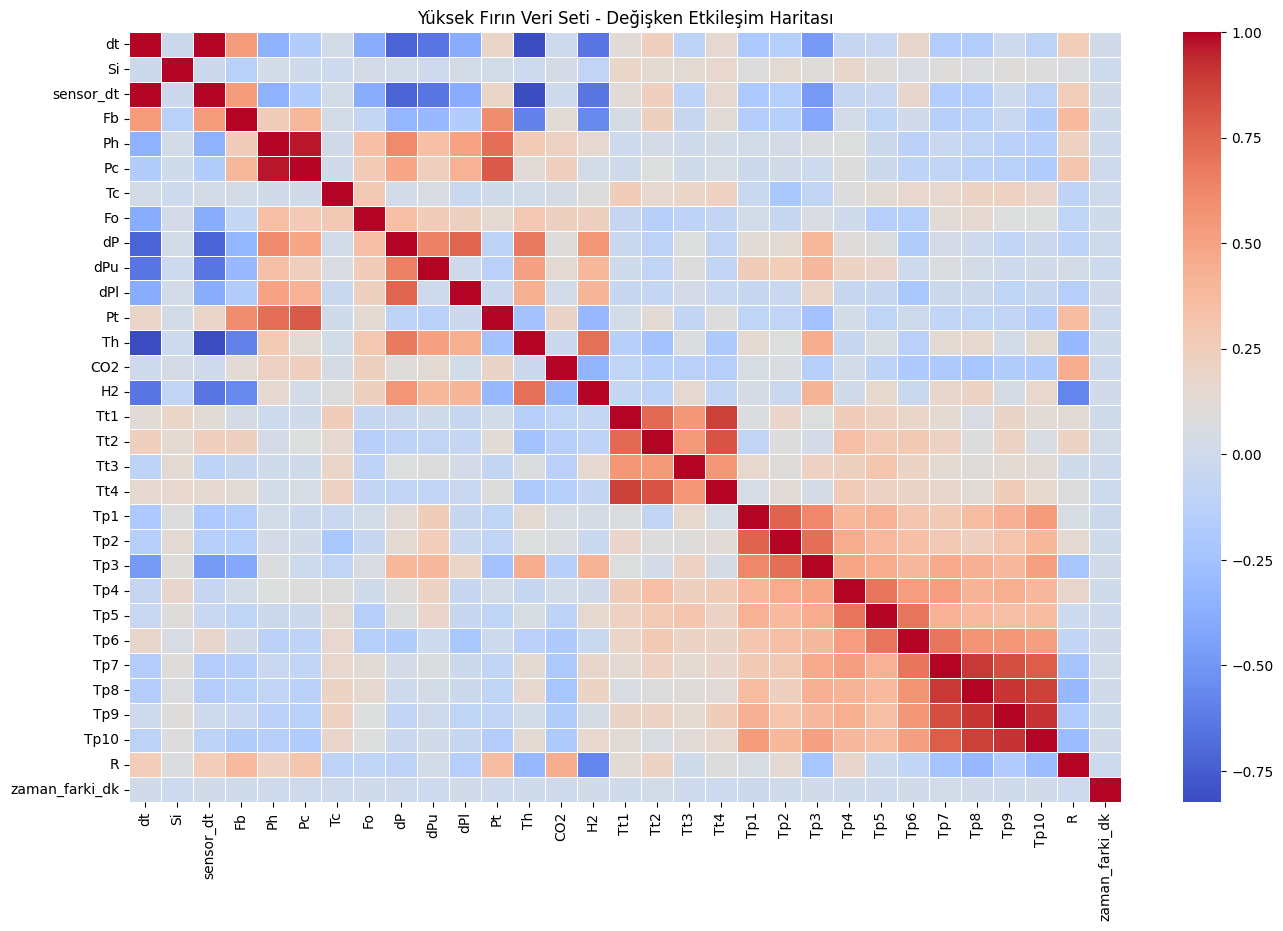


--- SİLİSYUM (Si) ÜZERİNDE EN ETKİLİ PARAMETRELER ---
Si                1.000
Tt1               0.186
Tp4               0.167
Tt4               0.165
Tt2               0.134
Tp2               0.134
Tt3               0.131
Tp3               0.106
Tp7               0.101
Tp5               0.101
Tp9               0.099
Tp10              0.095
Tp1               0.089
R                 0.073
Tp8               0.072
Tp6               0.054
Fo                0.030
CO2               0.025
dPl               0.022
Ph                0.018
dP                0.014
Pt                0.010
Pc                0.001
dPu              -0.005
Th               -0.012
zaman_farki_dk   -0.014
Tc               -0.017
sensor_dt        -0.024
dt               -0.024
H2               -0.083
Fb               -0.136
Name: Si, dtype: float64


In [17]:
df_final.to_csv('blast_furnace_gold_data.csv', index=False)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))
# Silisyum ile en çok korele olan değişkenleri görmek için
correlation_matrix = df_final.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Yüksek Fırın Veri Seti - Değişken Etkileşim Haritası')
plt.show()

# 3. Silisyum'un En Yakın Dostlarını Listele
print("\n--- SİLİSYUM (Si) ÜZERİNDE EN ETKİLİ PARAMETRELER ---")
print(correlation_matrix['Si'].sort_values(ascending=False))

In [ ]:
print()